<a href="https://colab.research.google.com/github/iamviplavkr/viplav_kumar_23FE10CSE00421_ML/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df = pd.read_csv("/content/sample_data/student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
l_column = list(df.columns) # Making a list out of column names
len_feature = len(l_column) # Length of column vector list
l_column

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [5]:
df.info(verbose="true")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
num_cols = df.select_dtypes(include=['int64']).columns
num_cols


Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [10]:
X = df[num_cols].drop('G3', axis=1)
y = df['G3']


In [11]:
print("Feature set size:", X.shape)
print("Variable set size:", y.shape)


Feature set size: (649, 15)
Variable set size: (649,)


In [12]:
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,18,4,4,2,2,0,4,3,4,1,1,3,4,0,11
1,17,1,1,1,2,0,5,3,3,1,1,3,2,9,11
2,15,1,1,1,2,0,4,3,2,2,3,3,6,12,13
3,15,4,2,1,3,0,3,2,2,1,1,5,0,14,14
4,16,3,3,1,2,0,4,3,2,1,2,5,0,11,13


In [13]:
y.head()

,G3
0,11
1,11
2,12
3,14
4,13


In [14]:
from sklearn.model_selection import train_test_split


In [15]:
X = df.select_dtypes(include=['int64']).drop('G3', axis=1)
y = df['G3']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123
)


In [17]:
print("Training feature set size:", X_train.shape)
print("Test feature set size:", X_test.shape)
print("Training variable set size:", y_train.shape)
print("Test variable set size:", y_test.shape)


Training feature set size: (454, 15)
Test feature set size: (195, 15)
Training variable set size: (454,)
Test variable set size: (195,)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [19]:
lm = LinearRegression() # Creating a Linear Regression object 'lm'

In [20]:
lm.fit(X_train,y_train) # Fit the linear model on to the 'lm' object itself i.e. no need to set this to another variable

LinearRegression()

In [21]:
print("The intercept term of the linear model:", lm.intercept_)

The intercept term of the linear model: -0.2959431287423886


In [22]:
print("The coefficients of the linear model:", lm.coef_)

The coefficients of the linear model: [ 0.03689392 -0.0770352   0.06593785  0.08111667  0.08817216 -0.21129746
 -0.06830099 -0.03068295 -0.01448513 -0.06287058  0.00445017 -0.01717038
  0.0212173   0.12232548  0.90536597]


In [23]:
#idict = {'Coefficients':lm.intercept_}
#idf = pd.DataFrame(data=idict,index=['Intercept'])
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
#cdf=pd.concat([idf,cdf], axis=0)
cdf

,Coefficients
age,0.036894
Medu,-0.077035
Fedu,0.065938
traveltime,0.081117
studytime,0.088172
failures,-0.211297
famrel,-0.068301
freetime,-0.030683
goout,-0.014485
Dalc,-0.062871


In [25]:
# Number of observations and features
n = X_train.shape[0]
k = X_train.shape[1]

# Degrees of freedom
dfN = n - k

# Predictions on training set
train_pred = lm.predict(X_train)

# Sum of squared errors
train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

# Standard error list
se = []

for i in range(k):
    r = (sum_error / dfN)
    r = r / np.sum(
        np.square(
            X_train.iloc[:, i] - X_train.iloc[:, i].mean()
        )
    )
    se.append(np.sqrt(r))

# Add to dataframe
cdf['Standard Error'] = se

# t-statistic
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']

cdf


,Coefficients,Standard Error,t-statistic
age,0.036894,0.048819,0.755733
Medu,-0.077035,0.053235,-1.447088
Fedu,0.065938,0.054598,1.207693
traveltime,0.081117,0.081972,0.989566
studytime,0.088172,0.070392,1.252595
failures,-0.211297,0.101672,-2.078237
famrel,-0.068301,0.061730,-1.106455
freetime,-0.030683,0.058178,-0.527401
goout,-0.014485,0.050958,-0.284256
Dalc,-0.062871,0.064695,-0.971805


In [26]:
print("Therefore, features arranged in the order of importance for predicting the house price\n",'-'*90,sep='')
l=list(cdf.sort_values('t-statistic',ascending=False).index)
print(' > \n'.join(l))

Therefore, features arranged in the order of importance for predicting the house price
------------------------------------------------------------------------------------------
G2 > 
G1 > 
absences > 
studytime > 
Fedu > 
traveltime > 
age > 
Walc > 
goout > 
health > 
freetime > 
Dalc > 
famrel > 
Medu > 
failures


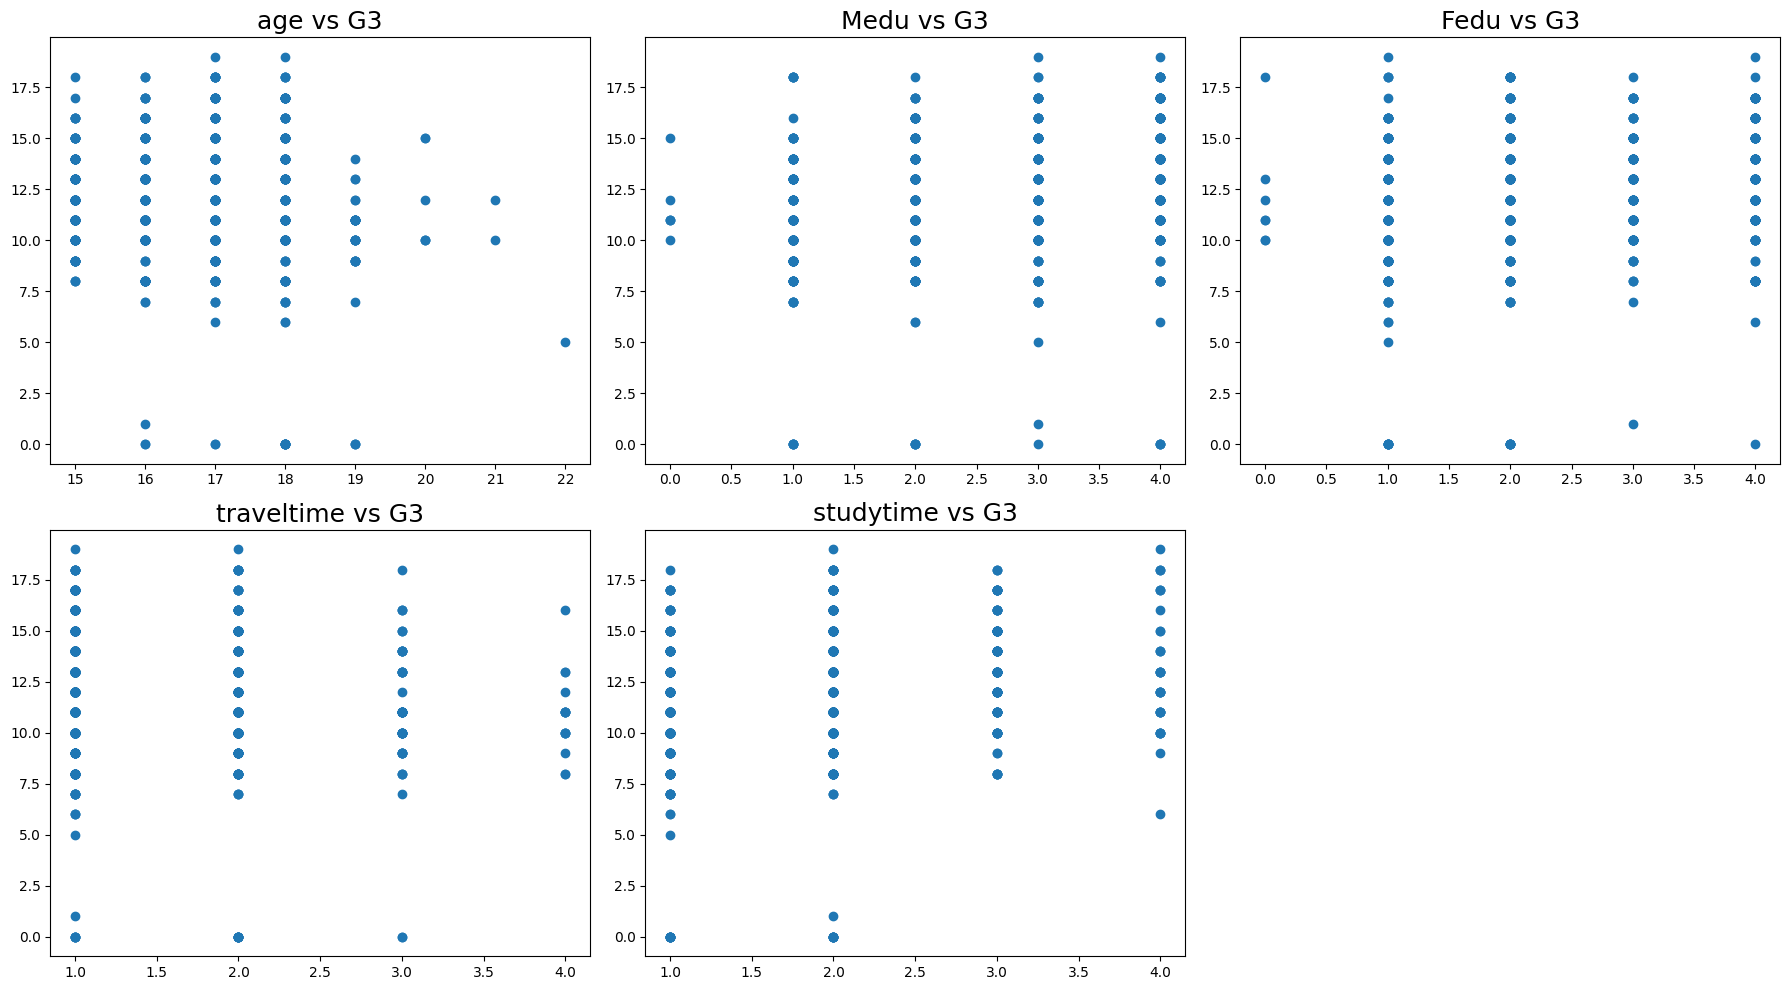

In [28]:
from matplotlib import gridspec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3)

# Plot 1
ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df['G3'])
ax0.set_title(l[0] + " vs G3", fontdict={'fontsize': 18})

# Plot 2
ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]], df['G3'])
ax1.set_title(l[1] + " vs G3", fontdict={'fontsize': 18})

# Plot 3
ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]], df['G3'])
ax2.set_title(l[2] + " vs G3", fontdict={'fontsize': 18})

# Plot 4
ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]], df['G3'])
ax3.set_title(l[3] + " vs G3", fontdict={'fontsize': 18})

# Plot 5
ax4 = plt.subplot(gs[4])
ax4.scatter(df[l[4]], df['G3'])
ax4.set_title(l[4] + " vs G3", fontdict={'fontsize': 18})

plt.tight_layout()
plt.show()


In [30]:
predictions = lm.predict(X_test)
residuals = y_test - predictions


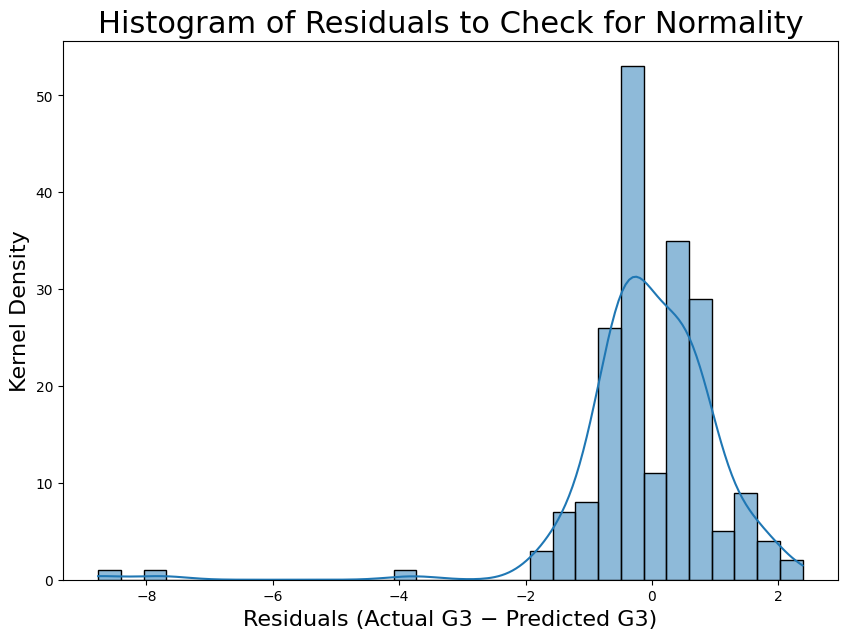

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
plt.title("Histogram of Residuals to Check for Normality", fontsize=22)
plt.xlabel("Residuals (Actual G3 − Predicted G3)", fontsize=16)
plt.ylabel("Kernel Density", fontsize=16)

sns.histplot(residuals, kde=True)

plt.show()


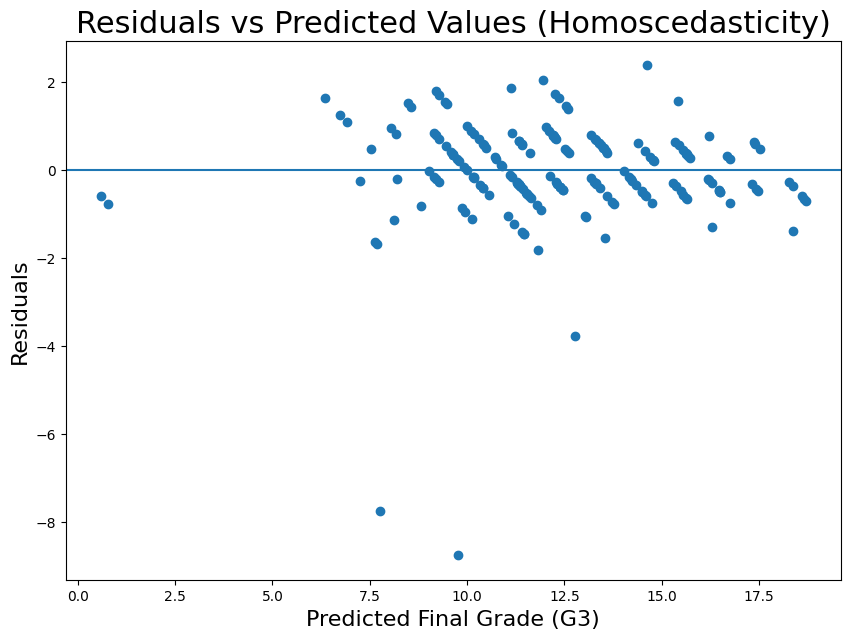

In [32]:
residuals = y_test - predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Residuals vs Predicted Values (Homoscedasticity)", fontsize=22)
plt.xlabel("Predicted Final Grade (G3)", fontsize=16)
plt.ylabel("Residuals", fontsize=16)

plt.scatter(x=predictions, y=residuals)

# Reference line at zero
plt.axhline(y=0)

plt.show()


In [33]:
print("Mean absolute error (MAE):", metrics.mean_absolute_error(y_test,predictions))
print("Mean square error (MSE):", metrics.mean_squared_error(y_test,predictions))
print("Root mean square error (RMSE):", np.sqrt(metrics.mean_squared_error(y_test,predictions)))

Mean absolute error (MAE): 0.7384954114323072
Mean square error (MSE): 1.3852108877804796
Root mean square error (RMSE): 1.1769498238159857


In [34]:
print("R-squared value of predictions:",round(metrics.r2_score(y_test,predictions),3))

R-squared value of predictions: 0.865


In [35]:
#compute minmax value for observed price and expected price
import numpy as np
min=np.min(predictions/6000)
max=np.max(predictions/12000)
print(min, max)

9.978910663931819e-05 0.0015577510711620383


(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([68588.3264881, 68588.4264881, 68588.5264881, 68588.6264881,
        68588.7264881, 68588.8264881, 68588.9264881, 68589.0264881,
        68589.1264881, 68589.2264881, 68589.3264881]),
 <BarContainer object of 10 artists>)

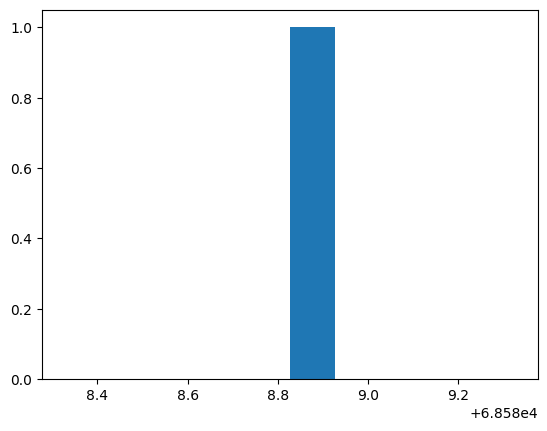

In [36]:
#Compute MinMax value for Price=100
L = (100 - min)/(max - min)
L
plt.hist(L)